# Modelo bidimensional simplificado de escoamento em canal inspirado no Backward-Facing Step via diferenças finitas

## Introdução

A Dinâmica dos Fluidos Computacional (Computational Fluid Dynamics – CFD) constitui uma importante ferramenta para a análise e compreensão de fenômenos de escoamento presentes em diversos problemas de engenharia, como sistemas de transporte de fluidos, máquinas hidráulicas, aerodinâmica e processos industriais. Entre os problemas clássicos de CFD, destaca-se o escoamento em canal com degrau (*Backward-Facing Step* – BFS), amplamente utilizado como benchmark para validação de modelos numéricos devido à presença de fenômenos complexos, como separação da camada limite, recirculação e reanexação do escoamento.

A modelagem completa do problema de BFS é governada pelas equações de Navier-Stokes bidimensionais, cuja resolução numérica exige o emprego de métodos computacionais avançados, como volumes finitos, elementos finitos ou diferenças finitas aplicadas a Equações Diferenciais Parciais (EDPs). Entretanto, para fins didáticos e em conformidade com os objetivos desta atividade, propõe-se a construção de um modelo simplificado, capaz de preservar o contexto físico do problema sem a necessidade de resolver toda a complexidade do escoamento.

Assim, considera-se uma região do canal suficientemente distante da zona de recirculação, na qual o escoamento pode ser aproximado como laminar, permanente, incompressível e totalmente desenvolvido. Sob essas hipóteses, as componentes convectivas tornam-se desprezíveis e o problema reduz-se a uma Equação Diferencial Ordinária (EDO) de segunda ordem que descreve a distribuição de velocidade na direção transversal ao escoamento.

A equação governante simplificada (**Equação de Poisson**) pode ser escrita como:

$$\frac{\partial ^2u}{\partial x^2} + \frac{\partial ^2u}{\partial y^2}=\frac{1}{\mu}\frac{\partial p}{\partial x}$$

ou, de forma equivalente,

$$\frac{\partial ^2u}{\partial x^2} + \frac{\partial ^2u}{\partial y^2}=S(x,y)$$

em que (u(y)) representa a velocidade do fluido, ($\mu$) é a viscosidade dinâmica e (C) corresponde a um gradiente de pressão constante.

A resolução dessa EDO será realizada por meio do Método das Diferenças Finitas (MDF), uma das técnicas numéricas mais utilizadas para a discretização de equações diferenciais. O método consiste em substituir as derivadas contínuas por aproximações algébricas obtidas a partir de uma malha discreta do domínio, convertendo o problema diferencial em um sistema de equações lineares passível de solução computacional.

Como etapa complementar, propõe-se a organização do desenvolvimento em um pipeline computacional estruturado, contemplando a formulação física do problema, a discretização numérica, a implementação computacional, a validação por meio da solução analítica e a análise de convergência da solução. Essa abordagem permite não apenas o estudo dos fundamentos de métodos numéricos aplicados à mecânica dos fluidos, mas também estabelece uma ponte conceitual com problemas de maior complexidade, como as simulações CFD do *Backward-Facing Step* e as pesquisas em modelagem computacional baseada em física.

## 1. Definição do Problema Físico

Considera-se uma região simplificada do escoamento após o degrau (*Backward-Facing Step* – BFS), suficientemente distante da zona de recirculação, onde o comportamento do fluido pode ser aproximado por um modelo bidimensional estacionário de difusão. Essa formulação constitui uma evolução do modelo unidimensional anteriormente estudado, permitindo a análise da distribuição espacial da velocidade em duas dimensões.

A equação governante é dada por:

$$
\nabla^2 u = S_u(x,y)
$$

ou, de forma expandida,

$$
\frac{\partial^2 u}{\partial x^2}
+
\frac{\partial^2 u}{\partial y^2}
=

S_u(x,y)
$$

trata-se de uma Equação Diferencial Parcial (EDP) elíptica do tipo Poisson, frequentemente utilizada para modelar fenômenos difusivos em regime estacionário.

O termo fonte é definido como:

$$
S_u(x,y)
=

C\left[
1+\alpha\sin(\pi x)\sin(\pi y)
\right]
$$

Logo, a equação governante pode ser escrita como:

$$
\frac{\partial^2 u}{\partial x^2}
+
\frac{\partial^2 u}{\partial y^2}
=

C\left[
1+\alpha\sin(\pi x)\sin(\pi y)
\right]
$$

onde:

* $S_u(x,y)$ é o termo fonte espacialmente variável;
* $C$ representa a intensidade média da força motriz associada ao gradiente de pressão;
* $\alpha$ é um parâmetro adimensional que controla a amplitude da perturbação;
* $\sin(\pi x)\sin(\pi y)$ introduz uma variação espacial bidimensional no termo fonte, produzindo um campo de velocidades não uniforme.

As condições de contorno adotadas são do tipo Dirichlet homogêneas:

$$
u(0,y)=0,
\qquad
u(L,y)=0,
$$

$$
u(x,0)=0,
\qquad
u(x,H)=0.
$$

Essas condições representam, de forma simplificada, a condição de não deslizamento (*no-slip*) nas fronteiras do domínio bidimensional considerado.

Ressalta-se que essa formulação não corresponde ao problema completo do *Backward-Facing Step*, governado pelas equações de Navier-Stokes bidimensionais. Trata-se de uma aproximação matemática inspirada no contexto do BFS, proposta com o objetivo de estudar a aplicação do Método das Diferenças Finitas em uma EDP bidimensional e analisar suas propriedades de convergência e precisão numérica.

## 2.Escolher parâmetros

Usando C<0 para gerar um perfil positivo de velocidade.

In [1]:
# Bibliotecas
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

## 3. Montar o sistema linear

Para os pontos internos:

$$\frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{\Delta x^2} + 
\frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{\Delta y^2} 
= S_{i,j}$$

## Definindo as matrizes de coeficientes

$$A_w u_{i-1,j} + A_e u_{i+1,j} + A_s u_{i,j-1} + A_n u_{i,j+1} + A_p u_{i,j} = S_{i,j}

In [2]:
precisao = 1e-6
max_iter = 20000

C = -2.0
alpha = 10.0

L_total = 4.0
H_total = 1.0
L_step = 1.0
h_step = 0.5

Nx = 120*1
Ny = 40*1

x = np.linspace(0, L_total, Nx)
y = np.linspace(0, H_total, Ny)

dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing="ij")

u = np.zeros((Nx, Ny), dtype=float)

valid = np.ones((Nx, Ny), dtype=bool)
valid[(X <= L_step) & (Y <= h_step)] = False

Aw = 1.0 / dx**2
Ae = 1.0 / dx**2
As = 1.0 / dy**2
An = 1.0 / dy**2
Ap = -2.0 * (1.0 / dx**2 + 1.0 / dy**2)

for it in range(1, max_iter + 1):
    u_old = u.copy()

    # região sólida zerada
    u[~valid] = 0.0

    # contornos externos
    u[0, :] = 0.0      # x = 0
    u[-1, :] = 0.0     # x = L_total
    u[:, 0] = 0.0      # y = 0
    u[:, -1] = 0.0     # y = H_total

    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):

            if not valid[i, j]:
                continue

            Su = C * (
                1.0
                + alpha * np.sin(np.pi * X[i, j] / L_total)
                * np.sin(np.pi * Y[i, j] / H_total)
            )

            u[i, j] = (1.0 / Ap) * (
                Su
                - Aw * u[i - 1, j]
                - Ae * u[i + 1, j]
                - As * u[i, j - 1]
                - An * u[i, j + 1]
            )

    erro = np.max(np.abs(u - u_old))

    if it % 200 == 0 or erro < precisao:
        print(f"Iter {it:5d} | erro = {erro:.3e}")

    if erro < precisao:
        print(f"Convergiu em {it} iterações.")
        break

print("U min/max:", u[valid].min(), u[valid].max())

Iter   200 | erro = 3.932e-03
Iter   400 | erro = 1.612e-03
Iter   600 | erro = 6.547e-04
Iter   800 | erro = 2.648e-04
Iter  1000 | erro = 1.069e-04
Iter  1200 | erro = 4.310e-05
Iter  1400 | erro = 1.738e-05
Iter  1600 | erro = 7.005e-06
Iter  1800 | erro = 2.824e-06
Iter  2000 | erro = 1.139e-06
Iter  2029 | erro = 9.982e-07
Convergiu em 2029 iterações.
U min/max: 0.0 2.1124719138176613


## Plotagem do gráfico de intensidade da componente horizontal da velocidade ($u(x,y)$)

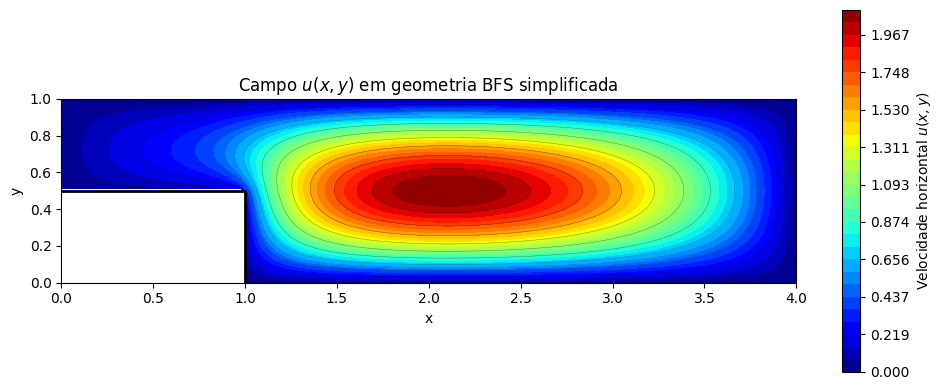

In [3]:
# Máscara do domínio sólido
u_plot = np.ma.masked_where(~valid, u)

# Malha para plotagem
X, Y = np.meshgrid(x, y, indexing="ij")

plt.figure(figsize=(10, 4))

levels = np.linspace(
    u_plot.min(),
    u_plot.max(),
    30
)

cf = plt.contourf(
    X,
    Y,
    u_plot,
    levels=levels,
    cmap='jet'
)

plt.contour(
    X,
    Y,
    u_plot,
    levels=levels[::3],
    colors='k',
    linewidths=0.3,
    alpha=0.5
)

# Desenha o degrau do BFS
plt.plot(
    [0, L_step, L_step],
    [h_step, h_step, 0],
    'k',
    linewidth=2
)

cbar = plt.colorbar(cf)
cbar.set_label(r'Velocidade horizontal $u(x,y)$')

plt.xlim(0, L_total)
plt.ylim(0, H_total)
plt.gca().set_aspect('equal', adjustable='box')

plt.xlabel('x')
plt.ylabel('y')
plt.title(r'Campo $u(x,y)$ em geometria BFS simplificada')

plt.tight_layout()
plt.show()